In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, f1_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# load data preprocessed
train = pd.read_csv('../data/train_processed.csv')

print("Data berhasil diload!")
print("Shape:", train.shape)
train.head()

Data berhasil diload!
Shape: (20631, 49)


,engine_id,cycle,setting_1,setting_2,setting_3,s2,s3,s4,s7,s8,...,s14_rmean,s14_rstd,s15_rmean,s15_rstd,s17_rmean,s17_rstd,s20_rmean,s20_rstd,s21_rmean,s21_rstd
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,0.726248,0.242424,...,0.199608,0.000000,0.363986,0.000000,0.333333,0.000000,0.713178,0.000000,0.724662,0.000000
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,0.628019,0.212121,...,0.181211,0.026018,0.387649,0.033464,0.333333,0.000000,0.689922,0.032889,0.727838,0.004491
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,0.710145,0.272727,...,0.178071,0.019184,0.377581,0.029394,0.277778,0.096225,0.669251,0.042694,0.692350,0.061548
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,0.740741,0.318182,...,0.177276,0.015744,0.324836,0.108185,0.291667,0.083333,0.645349,0.059164,0.684859,0.052440
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,0.668277,0.242424,...,0.176767,0.013682,0.340285,0.099856,0.316667,0.091287,0.634109,0.057070,0.688788,0.046256


In [2]:
from sklearn.model_selection import train_test_split

exclude_cols = ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3','RUL', 'label' ]
feature_cols = [col for col in train.columns if col not in exclude_cols]

X = train[feature_cols]
y = train['label']

#split 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

print(f"Fitur yang dipakai: {len(feature_cols)} kolom")

print(f"X_train : {X_train.shape}")
print(f"X_val : {X_val.shape}")
print(f"y_train - Normal: {sum(y_train == 0)}, Kritis: {sum(y_train==1)}")
print(f"y_val - Normal: {sum(y_val==0)}, Kritis: {sum(y_val==1)}")

Fitur yang dipakai: 42 kolom
X_train : (16504, 42)
X_val : (4127, 42)
y_train - Normal: 14024, Kritis: 2480
y_val - Normal: 3507, Kritis: 620


In [3]:
# inisialisasi model
#class_weight='balanced = otomatis kasih bobot lebih ke kelas minoritas (kritis)
#supata model ga "males" dan selalu prediksi normal

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

#training
print("Training model nih")
rf_model.fit(X_train, y_train)
print("beres training")

#prediksi di validation set
y_pred = rf_model.predict(X_val)

#evaluasi
print("\nHasil Evaluasi")
print(classification_report(y_val, y_pred, target_names=["Normal", "Kritis"]))

Training model nih
beres training

Hasil Evaluasi
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      3507
      Kritis       0.92      0.89      0.90       620

    accuracy                           0.97      4127
   macro avg       0.95      0.94      0.94      4127
weighted avg       0.97      0.97      0.97      4127



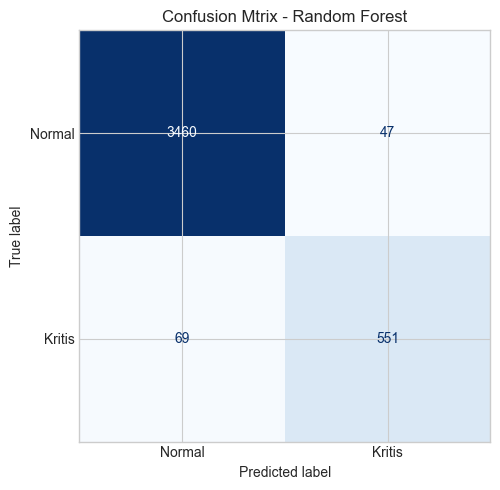

In [4]:
#confusion matriks
fig, ax = plt.subplots(figsize=(6,5))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Kritis'])
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Mtrix - Random Forest")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_rf.png", dpi=150)
plt.show()

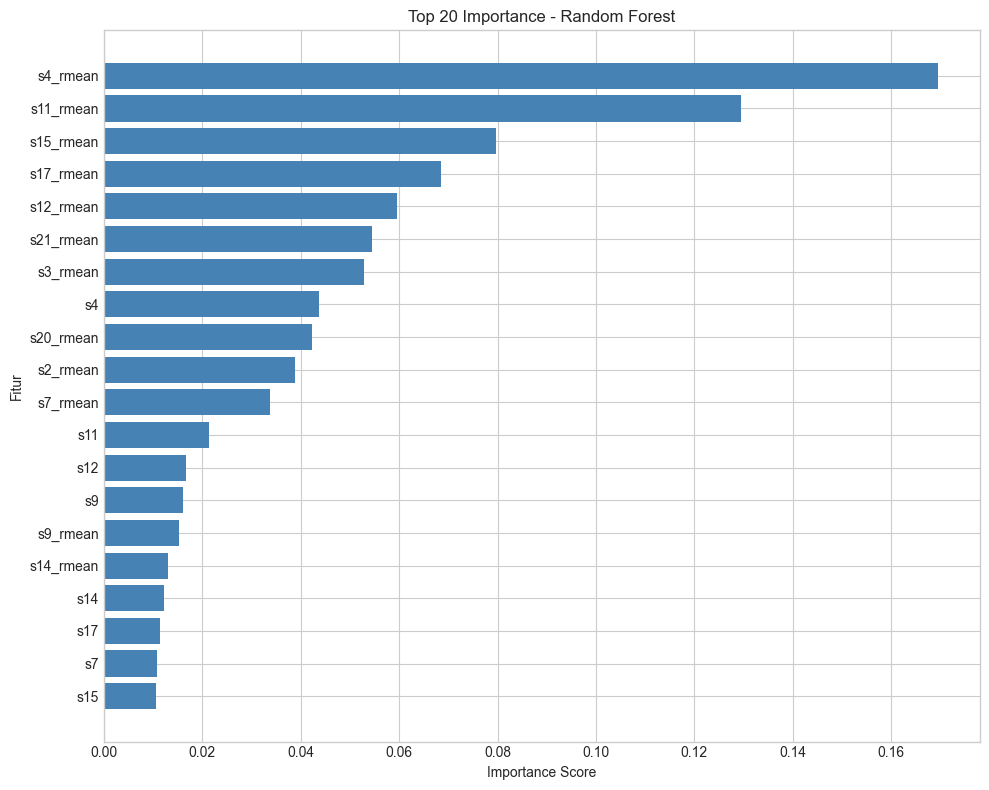

In [5]:
#ambil feature importance dari model
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

#plot 20 fitur terpenting
plt.figure(figsize=(10,8))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title("Top 20 Importance - Random Forest")
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

In [6]:
from xgboost import XGBClassifier

#hitung scale_plot_weight untuk handel imbalance data
#ini equivalent dengan class_weight = 'balance di random forest

negative = sum(y_train == 0)
positive = sum(y_train == 1)
scale = negative/positive

print(f"Scale pos weight: {scale:.2f}")
print("(artinya kelas kritis dapat bobot: {:.1f}x lebih besar)".format(scale))

#inisialisasi XGBoost
xgb_model = XGBClassifier(
    n_estimators = 100,
    scale_pos_weight=scale,
    random_state = 42,
    n_jobs=-1,
    verbosity = 0
)

#training
print("\n Training XGBoost")
xgb_model.fit(X_train, y_train)
print("Training selesai")

#prediksi & evaluasi
y_pred_xgb = xgb_model.predict(X_val)

print("Hasil Evaluasi")
print(classification_report(y_val, y_pred_xgb, target_names = ['Normal', 'Kritis']))

Scale pos weight: 5.65
(artinya kelas kritis dapat bobot: 5.7x lebih besar)

 Training XGBoost
Training selesai
Hasil Evaluasi
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      3507
      Kritis       0.90      0.94      0.92       620

    accuracy                           0.98      4127
   macro avg       0.95      0.96      0.95      4127
weighted avg       0.98      0.98      0.98      4127



Model tersimpan!


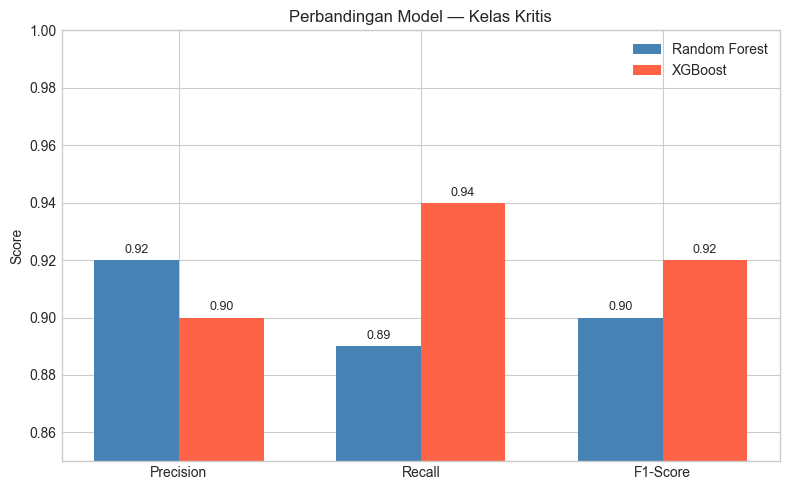

Plot tersimpan!


In [8]:
import joblib

# simpan model terbaik
joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')
print("Model tersimpan!")

# visualisasi perbandingan
metrics = {
    'Random Forest': {
        'Precision': 0.92, 'Recall': 0.89, 'F1-Score': 0.90
    },
    'XGBoost': {
        'Precision': 0.90, 'Recall': 0.94, 'F1-Score': 0.92
    }
}

x = np.arange(3)
width = 0.35
labels = ['Precision', 'Recall', 'F1-Score']

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, list(metrics['Random Forest'].values()), 
               width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, list(metrics['XGBoost'].values()), 
               width, label='XGBoost', color='tomato')

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Model — Kelas Kritis')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.2f', fontsize=9)
ax.bar_label(bars2, padding=3, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()
print("Plot tersimpan!")